In [1]:
import pandas as pd
import json

In [2]:
original_path = "../data/external/all_examples_og_prompt_with_position_info_and_success_V2.json"
scale_folder = "../outputs/all_scale"

In [3]:
from collections import Counter

def any_repeated_substring(s, min_repeats=5, max_sub_len=10):
    n = len(s)
    L = max_sub_len
    counts = Counter(s[i:i+L] for i in range(n - L + 1))
    if any(v >= min_repeats for v in counts.values()):
        # print("The max repeating subsequence is - ",counts.most_common(1)[0][0])
        return True
    return False


def _downgrade_plan_to_degenerate(steered_text, original_ym = None):
    """
        - empty string, single character, single string, then classify sa degen.
        - multiple number of 'import' statements in the output without any return statement at the end.
    """
    ## if original_ym is part of the steered text, it's marked as degenerate to prevent a False Positive.
    if original_ym != None and original_ym in steered_text:
        return True

    stripped_text = steered_text.strip()
    if stripped_text == "" or (" " not in stripped_text and len(stripped_text) >= 10):
        return True
    if any_repeated_substring(steered_text) and (original_ym == "return" or (original_ym != "return" and "return" not in steered_text)):
        return True
    # if original_ym == "return": ## added condition, don't consider planning at 'return' as actual planning evidence of anything actually code related.
    #     return True
    
    return False

In [4]:
def _classify_as_planning_vs_not_planning(steering_results, planning_analysis):
    """
        Logic:
            - if already marked as 'Not planning', we keep as-is.
            - if marked as planning, we check for non-degeneracy.
            - if marked as can't say, we check for non-degenaracy and whether the original and new normalized sequences differ by much.
        
        Returns, new planning analysis, with 
        {
            "y_m": {
                "original_verdict": 
                "new_verdict":
             }
            ....
        }
    """
    ym_keys = list(planning_analysis.keys())
    new_planning_analysis = {}
    for y_m in ym_keys:
        new_verdict = planning_analysis[y_m]
        base_suffix = steering_results[y_m]["base_text"]
         
        # if y_m == "return":
        #     new_verdict = "Not planning"
        if planning_analysis[y_m] == "Plan":  
            if not base_suffix.startswith(y_m) and not all(_downgrade_plan_to_degenerate(e.get("decoded_text", ""), y_m) for e in steering_results[y_m]["steered"]):
                new_verdict = "Plan"
            else:
                new_verdict = "Can't say"                
        
        new_planning_analysis[y_m] = {
            "original_verdict": planning_analysis[y_m],
            "new_verdict": new_verdict
        }
    
    return new_planning_analysis

In [5]:
import glob
all_tokens = [*glob.glob(scale_folder + "/base/*/*"), *glob.glob(scale_folder + "/instruct/*/*")]

In [6]:
len(all_tokens), all_tokens[0]

(1997, '../outputs/all_scale/base/prompt_0/token_188')

In [7]:
def dump_json(filename, my_dict):
    with open(filename, "w") as f:
        json.dump(my_dict, f, indent=4)  # indent=4 makes it pretty-printed

def load_json(file):
    try:
        with open(file, "r") as f:
            return json.load(f)
    except Exception as e:
        print(f"Exception when loading file {file}")
        raise e

In [8]:
import os

for token_planning_folder in all_tokens:
    # json_files = glob.glob(f"{token_planning_folder}/*.json")
    # metadata, planning_analysis, steering_results = load_json(json_files[1]), load_json(json_files[2]), load_json(json_files[3])
    planning_analysis = load_json(f"{token_planning_folder}/planning_analysis.json")
    steering_results = load_json(f"{token_planning_folder}/steering_results.json")
    new_planning_analysis = _classify_as_planning_vs_not_planning(steering_results, planning_analysis)
    updated_folder = token_planning_folder.replace("all_scale", "t_all_scale")
    os.makedirs(updated_folder, exist_ok=True)
    dump_json(updated_folder + "/updated_planning_analysis.json", new_planning_analysis)

In [9]:
def _detect_planning(planning_dict):
    keys = []
    for key, value in planning_dict.items():
        if value["new_verdict"] == "Plan":
            keys.append(key)
    return keys

def _detect_cant_says(planning_dict):
    present = False
    for key, value in planning_dict.items():
        if value["new_verdict"] == "Can't say":
            present = True
    return present

def _get_ym_plans(folder):
    token_planning_files = glob.glob(folder + "/*/*.json")
    planning_datas = [load_json(f) for f in token_planning_files]
    y_ms = []
    for data in planning_datas:
        y_ms.extend(_detect_planning(data))
    y_ms = list(set(y_ms))
    return y_ms

def _detect_cs(folder):
    token_planning_files = glob.glob(folder + "/*/*.json")
    planning_datas = [load_json(f) for f in token_planning_files]
    for data in planning_datas:
        if _detect_cant_says(data):
            return True
    return False

def _get_base_and_instruct_plans(iter, root_folder = "../outputs/t_all_scale"):
    base_folder = f"{root_folder}/base/prompt_{iter}"
    instruct_folder = f"{root_folder}/instruct/prompt_{iter}"
    base_yms = None
    instruct_yms = None
    if os.path.exists(base_folder):
        base_yms = _get_ym_plans(base_folder)
    if os.path.exists(instruct_folder):
        instruct_yms = _get_ym_plans(instruct_folder)
    return {
        "base": base_yms,
        "instruct": instruct_yms
    }

def _get_base_and_instruct_cantsays(iter, root_folder = "../outputs/t_all_scale"):
    base_folder = f"{root_folder}/base/prompt_{iter}"
    instruct_folder = f"{root_folder}/instruct/prompt_{iter}"
    if os.path.exists(base_folder):
        base_cs = _detect_cs(base_folder)
    else:
        base_cs = False
    if os.path.exists(instruct_folder):
        instruct_cs = _detect_cs(instruct_folder)
    else:
        instruct_cs = False
    return {
        "base": base_cs,
        "instruct": instruct_cs
    }

In [10]:
data = load_json("../data/external/all_examples_og_prompt_with_position_info_and_success_V2.json")

In [11]:
for iter, entry in enumerate(data):
    ym_plans = _get_base_and_instruct_plans(iter)
    entry["base_plans"] = ym_plans["base"]
    entry["instruct_plans"] = ym_plans["instruct"]
    cs = _get_base_and_instruct_cantsays(iter)    
    entry["base_cs"] = cs["base"]
    entry["instruct_cs"] = cs["instruct"]

In [12]:
def _get_4x4_grid(selected_cases, with_e = False):
    suffix = ""
    if with_e:
        suffix = "_e"
    instruct_plan_base_no_plan = []
    base_plan_instruct_no_plan = []
    both_plans = []
    no_plans = []
    for entry in selected_cases:
        base_planning, instruct_planning = False, False
        if entry["base_plans" + suffix] and len(entry["base_plans" + suffix]) > 0:
            base_planning = True
        elif entry["base_cs" + suffix] == True:
            continue ## skip case if can't say.    
        if entry["instruct_plans" + suffix] and len(entry["instruct_plans" + suffix]) > 0:
            instruct_planning = True
        elif entry["instruct_cs" + suffix] == True:
            continue ## similar skip.

        if base_planning:
            if instruct_planning:         
                both_plans.append(entry)
            else:
                base_plan_instruct_no_plan.append(entry)
        elif instruct_planning:
            instruct_plan_base_no_plan.append(entry)
        else:
            no_plans.append(entry)
    
    print({
        "Both": len(both_plans),
        "Only instruct": len(instruct_plan_base_no_plan),
        "Only base": len(base_plan_instruct_no_plan),
        "None": len(no_plans)
    })

    return {
        "Both": both_plans,
        "Only instruct": instruct_plan_base_no_plan, 
        "Only base": base_plan_instruct_no_plan,
        "None": no_plans 
    }

In [13]:
for idx, entry in enumerate(data):
    entry["index"] = idx

with open("../data/base_vs_instruct_oracle_V1.json", "w") as f:
    json.dump(data, f, indent = 2)

In [14]:
selected_cases = [case for case in data if case["instruct_pass"] == True and case["base_pass"] == False]
len(selected_cases)

85

In [15]:
result = _get_4x4_grid(selected_cases)

{'Both': 32, 'Only instruct': 7, 'Only base': 12, 'None': 7}


In [16]:
result['None']

[{'source_file': 'Benchmark Questions Verification V2.ipynb',
  'task_id': 251,
  'prompt': 'Write a function that takes in a list and an element and inserts the element before each element in the list, and returns the resulting list.',
  'code': 'def insert_element(list,element):\n list = [v for elt in list for v in (element, elt)]\n return list',
  'test_imports': [],
  'test_list': ["assert insert_element(['Red', 'Green', 'Black'] ,'c')==['c', 'Red', 'c', 'Green', 'c', 'Black']",
   "assert insert_element(['python', 'java'] ,'program')==['program', 'python', 'program', 'java']",
   "assert insert_element(['happy', 'sad'] ,'laugh')==['laugh', 'happy', 'laugh', 'sad']"],
  'instruct_code': 'def insert_element(list1, element):\n    new_list = []\n    for i in range(len(list1)):\n        new_list.append(element)\n        new_list.append(list1[i])\n    return new_list\n',
  'model_output': 'def insert_element(list, element):\n    new_list = []\n    for i in range(len(list)):\n        if 

In [17]:
selected_cases = [case for case in data if case["instruct_pass"] == False and case["base_pass"] == True]
len(selected_cases)

10

In [18]:
result = _get_4x4_grid(selected_cases)

{'Both': 4, 'Only instruct': 0, 'Only base': 3, 'None': 0}


In [19]:
selected_cases = [case for case in data if case["instruct_pass"] == False and case["base_pass"] == False]
len(selected_cases)

197

In [20]:
result = _get_4x4_grid(selected_cases)

{'Both': 91, 'Only instruct': 12, 'Only base': 25, 'None': 18}


In [21]:
selected_cases = [case for case in data if case["instruct_pass"] == True and case["base_pass"] == True]
len(selected_cases)

100

In [22]:
result = _get_4x4_grid(selected_cases)

{'Both': 27, 'Only instruct': 6, 'Only base': 12, 'None': 13}


### By earliest position logic.

In [23]:
def _not_planning(steered_text, original_ym = None):
    """
        - empty string, single character, single string, then classify sa degen.
        - multiple number of 'import' statements in the output without any return statement at the end.
    """
    ## if original_ym is part of the steered text, it's marked as degenerate to prevent a False Positive.
    if original_ym != None and original_ym in steered_text:
        return True

    # stripped_text = steered_text.strip()
    # if stripped_text == "" or (" " not in stripped_text and len(stripped_text) >= 10):
    #     return True
    # if any_repeated_substring(steered_text) and (original_ym == "return" or (original_ym != "return" and "return" not in steered_text)):
    #     return True
    # # if original_ym == "return": ## added condition, don't consider planning at 'return' as actual planning evidence of anything actually code related.
    # #     return True
    return False

def _classify_earliest_position_as_planning(steering_results, planning_analysis):
    """
        Logic : 
            If the output is degenerate, we downgrade the Planning to Can't Say.

        Returns, similar new_verdict with 
        {
            "Key": {
                "original_verdict": "",
                "new_verdict": "",
            }
        }
    """
    ym_keys = list(planning_analysis.keys())
    new_planning_analysis = {}
    for y_m in ym_keys:
        new_verdict = planning_analysis[y_m]["final_label"]
        base_suffix = steering_results[y_m]["base_text"]        
        if planning_analysis[y_m]["final_label"] == "Plan":  
            if not base_suffix.startswith(y_m) and not all([_downgrade_plan_to_degenerate(e.get("decoded_text", ""), y_m) for e in steering_results[y_m]["steered"]]):
            # if not base_suffix.startswith(y_m) and not all([_downgrade_plan_to_degenerate(e.get("decoded_text", ""), y_m) for e in steering_results[y_m]["steered"] if e["coeff"] >= -200]):
            #     if all([_not_planning(e.get("decoded_text", ""), y_m) for e in steering_results[y_m]["steered"] if e["coeff"] >= -200]):
            #         new_verdict = "Not planning"
            #     else:
            #         new_verdict = "Plan"
                new_verdict = "Plan"
            else:
                new_verdict = "Can't say"                
        
        new_planning_analysis[y_m] = {
            "original_verdict": planning_analysis[y_m]["final_label"],
            "new_verdict": new_verdict
        }
    
    return new_planning_analysis

for token_planning_folder in all_tokens:
    metadata = load_json(f"{token_planning_folder}/metadata.json")
    new_planning_analysis = {} ## no plans anyway.
    if metadata["earliest_position"] is not None:
        planning_analysis = load_json(f"{token_planning_folder}/earliest_position_planning_analysis.json")
        steering_results = load_json(f"{token_planning_folder}/earliest_position.json")
        new_planning_analysis = _classify_earliest_position_as_planning(steering_results, planning_analysis)
    updated_folder = token_planning_folder.replace("all_scale", "t_all_scale_e")
    os.makedirs(updated_folder, exist_ok=True)
    dump_json(updated_folder + "/updated_planning_analysis.json", new_planning_analysis)

In [24]:
for iter, entry in enumerate(data):
    ym_plans = _get_base_and_instruct_plans(iter, root_folder = "../outputs/t_all_scale_e")
    entry["base_plans_e"] = ym_plans["base"]
    entry["instruct_plans_e"] = ym_plans["instruct"]
    cs = _get_base_and_instruct_cantsays(iter, root_folder = "../outputs/t_all_scale_e")    
    entry["base_cs_e"] = cs["base"]
    entry["instruct_cs_e"] = cs["instruct"]

In [25]:
selected_cases = [entry for entry in data if entry["base_pass"] == False and entry["instruct_pass"] == True]
len(selected_cases)

85

In [26]:
result = _get_4x4_grid(selected_cases, with_e = True)

{'Both': 55, 'Only instruct': 9, 'Only base': 4, 'None': 3}


In [27]:
selected_cases = [entry for entry in data if entry["base_pass"] == True and entry["instruct_pass"] == True]
len(selected_cases)

100

In [28]:
result = _get_4x4_grid(selected_cases, with_e = True)

{'Both': 63, 'Only instruct': 12, 'Only base': 5, 'None': 5}


In [29]:
selected_cases = [entry for entry in data if entry["base_pass"] == False and entry["instruct_pass"] == False]
len(selected_cases)

197

In [30]:
result = _get_4x4_grid(selected_cases, with_e = True)

{'Both': 115, 'Only instruct': 22, 'Only base': 20, 'None': 8}


In [31]:
# result['None']

In [32]:
with open("../data/base_vs_instruct_oracle_V2.json", "w") as f:
    json.dump(data, f, indent = 2)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def _get_2x2_grid(selected_cases, with_e=False):
    suffix = "_e" if with_e else ""
    instruct_plan_base_no_plan = []
    base_plan_instruct_no_plan = []
    both_plans = []
    no_plans = []

    for entry in selected_cases:
        base_planning, instruct_planning = False, False

        if entry.get("base_plans" + suffix) and len(entry["base_plans" + suffix]) > 0:
            base_planning = True
        elif entry.get("base_cs" + suffix) is True:
            continue  # skip if can't say

        if entry.get("instruct_plans" + suffix) and len(entry["instruct_plans" + suffix]) > 0:
            instruct_planning = True
        elif entry.get("instruct_cs" + suffix) is True:
            continue  # skip if can't say

        if base_planning:
            if instruct_planning:
                both_plans.append(entry)
            else:
                base_plan_instruct_no_plan.append(entry)
        elif instruct_planning:
            instruct_plan_base_no_plan.append(entry)
        else:
            no_plans.append(entry)

    return {
        "Both": both_plans,
        "Only instruct": instruct_plan_base_no_plan,
        "Only base": base_plan_instruct_no_plan,
        "None": no_plans,
    }


def compute_4x4_counts(data, with_e=False):
    """
    4 quadrants = (instruct_pass, base_pass) combinations.
    Each quadrant is a 2x2 mini-grid with cells:
      [0,0]=Both Plans, [0,1]=Only Instruct Plans
      [1,0]=Only Base Plans, [1,1]=None Plan

    Layout (rows = instruct pass/fail, cols = base pass/fail):
      rows 0-1: Instruct Pass
      rows 2-3: Instruct Fail
      cols 0-1: Base Pass
      cols 2-3: Base Fail
    """
    # Order in each 2x2
    inner_order = ["Both", "Only instruct", "Only base", "None"]  # TL, TR, BL, BR

    # Confusion-style quadrant layout
    quadrants = [
        ((True,  True),  (0, 0),  "Instruct Pass / Base Pass"),
        ((True,  False), (0, 2),  "Instruct Pass / Base Fail"),
        ((False, True),  (2, 0),  "Instruct Fail / Base Pass"),
        ((False, False), (2, 2),  "Instruct Fail / Base Fail"),
    ]

    counts = np.zeros((4, 4), dtype=int)

    for (ip, bp), (r0, c0), _title in quadrants:
        selected = [case for case in data if case.get("instruct_pass") == ip and case.get("base_pass") == bp]
        buckets = _get_2x2_grid(selected, with_e=with_e)

        # Fill the 2x2
        counts[r0 + 0, c0 + 0] = len(buckets["Both"])         # TL
        counts[r0 + 0, c0 + 1] = len(buckets["Only instruct"])# TR
        counts[r0 + 1, c0 + 0] = len(buckets["Only base"])    # BL
        counts[r0 + 1, c0 + 1] = len(buckets["None"])         # BR

    return counts


def plot_4x4_plan_grid(data, with_e=False, ax=None, cmap="Blues"):
    counts = compute_4x4_counts(data, with_e=with_e)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    else:
        fig = ax.figure

    im = ax.imshow(counts, cmap=cmap)

    # ---- annotate counts in each cell
    vmax = counts.max() if counts.size else 1
    for r in range(4):
        for c in range(4):
            ax.text(
                c, r, str(counts[r, c]),
                ha="center", va="center",
                fontsize=12,
                color="white" if counts[r, c] > 0.6 * vmax else "black"
            )

    # ---- grid lines: thin cell lines + thick quadrant dividers
    ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    # Thick lines separating 2x2 quadrants
    ax.axhline(1.5, linewidth=3)
    ax.axhline(3.5, linewidth=3)
    ax.axvline(1.5, linewidth=3)
    ax.axvline(3.5, linewidth=3)

    # Outer box
    ax.axhline(-0.5, linewidth=3)
    ax.axvline(-0.5, linewidth=3)

    # ---- inner labels (inside each quadrant, positioned near the 2x2 corners)
    inner_labels = {
        (0, 0): "Both Plans",
        (0, 1): "Only Instruct Plans",
        (1, 0): "Only Base Plans",
        (1, 1): "None Plan",
    }
    # Put the same inner labels in all 4 quadrants, slightly inset
    for r0, c0 in [(0, 0), (0, 2), (2, 0), (2, 2)]:
        for (dr, dc), lab in inner_labels.items():
            r = r0 + dr
            c = c0 + dc
            # label slightly above the number
            ax.text(c, r - 0.32, lab, ha="center", va="center", fontsize=8)

    # ---- outer labels (2 layers): Instruct on left, Base on top
    ax.text(0.5, -0.95, "Base Pass", ha="center", va="center", fontsize=14)
    ax.text(2.5, -0.95, "Base Fail", ha="center", va="center", fontsize=14)

    ax.text(-0.95, 0.5, "Instruct Pass", ha="center", va="center", fontsize=14, rotation=90)
    ax.text(-0.95, 2.5, "Instruct Fail", ha="center", va="center", fontsize=14, rotation=90)

    # Optional: quadrant titles (center of each 2x2)
    quad_titles = {
        (0.5, 0.5): "IP / BP",
        (0.5, 2.5): "IP / BF",
        (2.5, 0.5): "IF / BP",
        (2.5, 2.5): "IF / BF",
    }
    for (y, x), t in quad_titles.items():
        ax.text(x, y, t, ha="center", va="center", fontsize=12, fontweight="bold")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    ax.set_xlim(-1.2, 3.5)
    ax.set_ylim(3.5, -1.2)  # keep (0,0) at top-left + room for labels
    ax.set_title("4×4 Grid: Pass/Fail quadrants × Planning categories", fontsize=14)
    return ax


# --- usage
# ax = plot_4x4_plan_grid(data, with_e=False)
# plt.show()

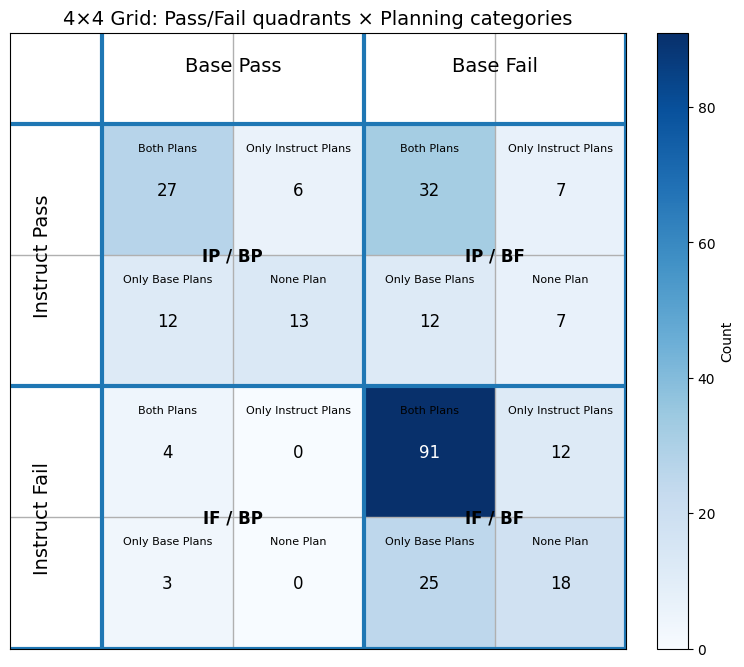

In [34]:
ax = plot_4x4_plan_grid(data, with_e = False)
plt.show()

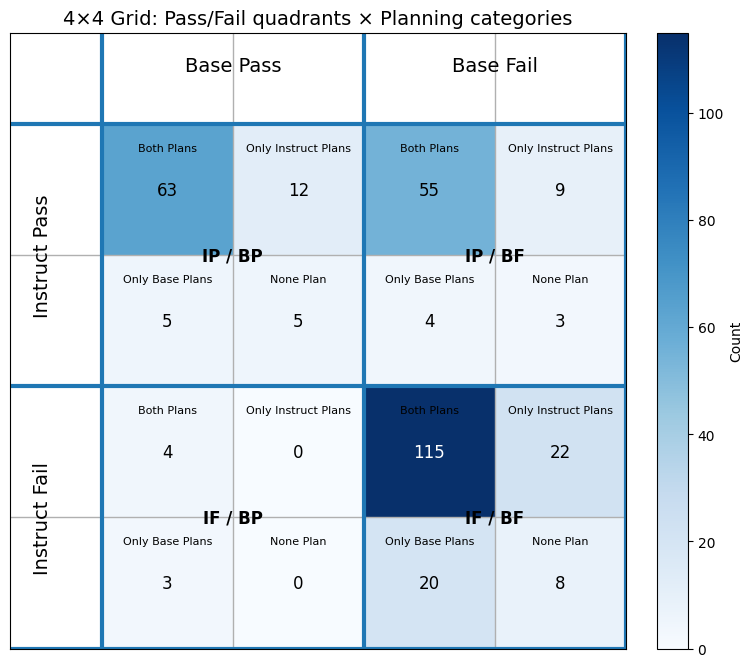

In [35]:
ax = plot_4x4_plan_grid(data, with_e = True)
plt.show()

In [36]:
len(data)

392

In [37]:
only_diff_data = [d for d in data if "position_info" in d.keys()]

In [38]:
len(only_diff_data)

364

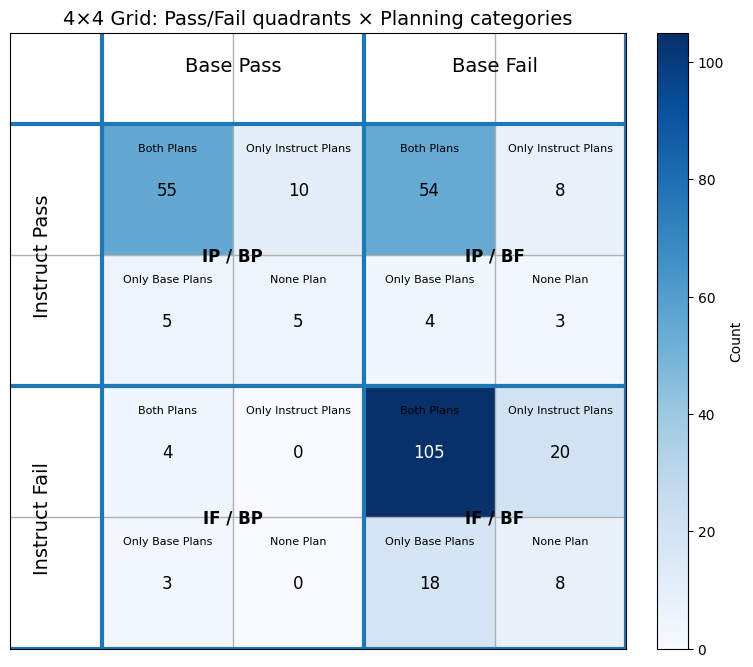

In [39]:
ax = plot_4x4_plan_grid(only_diff_data, with_e = True)
plt.show()

In [40]:
import ast

import difflib

def similarity(code1, code2):
    return difflib.SequenceMatcher(None, code1, code2).ratio()

def create_input_prompt_prefix(task_prompt, test_list, mode = "base"):
    prompt = (
            "You are an expert Python programmer, and here is your task: "
            f"{task_prompt} Your code should pass these tests:\n\n"
            + "\n".join(test_list) + "\nWrite your code below starting with \"```python\" and ending with \"```\".\n```python\n"
        )
    if mode == "instruct":
        prompt = (
            "You are an expert Python programmer, and here is your task: "
            f"{task_prompt} Your code should pass these tests:\n\n"
            + "\n".join(test_list) + "\nWrite your code, without docstrings, below starting with \"```python\" and ending with \"```\".\n```python\n"
        )
    
    return prompt

class Normalizer(ast.NodeTransformer):
    def __init__(self):
        self.var_map = {}
        self.func_map = {}
        self.class_map = {}
        self.counter = 0

    def _rename(self, name, mapping):
        if name not in mapping:
            mapping[name] = f"id_{len(mapping)}"
        return mapping[name]

    def visit_Name(self, node):
        node.id = self._rename(node.id, self.var_map)
        return node

    def visit_arg(self, node):
        node.arg = self._rename(node.arg, self.var_map)
        return node

    def visit_FunctionDef(self, node):
        node.name = self._rename(node.name, self.func_map)
        self.generic_visit(node)
        return node

    def visit_ClassDef(self, node):
        node.name = self._rename(node.name, self.class_map)
        self.generic_visit(node)
        return node

def normalize(code):
    try:
        tree = ast.parse(code)
        normalized = Normalizer().visit(tree)
        return ast.dump(normalized, annotate_fields=True, include_attributes=False)
    except:
        return None
    
def _extract_code_part(input_prefix_text, suffix_text):
    full_text = input_prefix_text + suffix_text
    return "def" + full_text.split("```python\n")[-1].split("def")[1]

from zss import simple_distance, Node

def to_zss(node):
    if not isinstance(node, ast.AST):
        return None
    children = []
    for f in node._fields:
        value = getattr(node, f)
        if isinstance(value, list):
            for child in value:
                if isinstance(child, ast.AST):
                    children.append(to_zss(child))
        elif isinstance(value, ast.AST):
            children.append(to_zss(value))
    return Node(node.__class__.__name__, children=children)

def normalize_ast(code):
    try:
        tree = ast.parse(code)
        norm = Normalizer().visit(tree)
        ast.fix_missing_locations(norm)
        return norm
    except Exception as e:
        return None
    
def _get_zss_sim(code1, code2, verbose = False):
    node1 = normalize_ast(code1)
    node2 = normalize_ast(code2)
    distance = simple_distance(to_zss(node1), to_zss(node2))
    return distance

def _filter_similar_answers(entry, distance_threshold = 4, similarity_threshold = 0.7):
    instruct_output = entry["instruct_code"]
    base_output = entry["model_output"]
    task = entry["prompt"]
    test_list = entry["test_list"]
    base_prefix = create_input_prompt_prefix(task, test_list, mode = "base")
    instruct_prefix = create_input_prompt_prefix(task, test_list, mode = "instruct")
    base_code = _extract_code_part(base_prefix, base_output)
    instruct_code = _extract_code_part(instruct_prefix, instruct_output)
    # normalized_base_code = normalize(base_code)
    # normalized_instruct_code = normalize(instruct_code)
    # if normalized_base_code != None and normalized_instruct_code != None:
    #     return similarity(normalized_base_code, normalized_instruct_code) < 0.8
    # else:
    #     return similarity(base_code, instruct_code) < 0.7
    try:
        distance = _get_zss_sim(base_code, instruct_code)
        return distance > distance_threshold
    except:
        return similarity(base_code, instruct_code) < similarity_threshold

In [41]:
more_diff_data = [entry for entry in data if _filter_similar_answers(entry)]
len(more_diff_data)

277

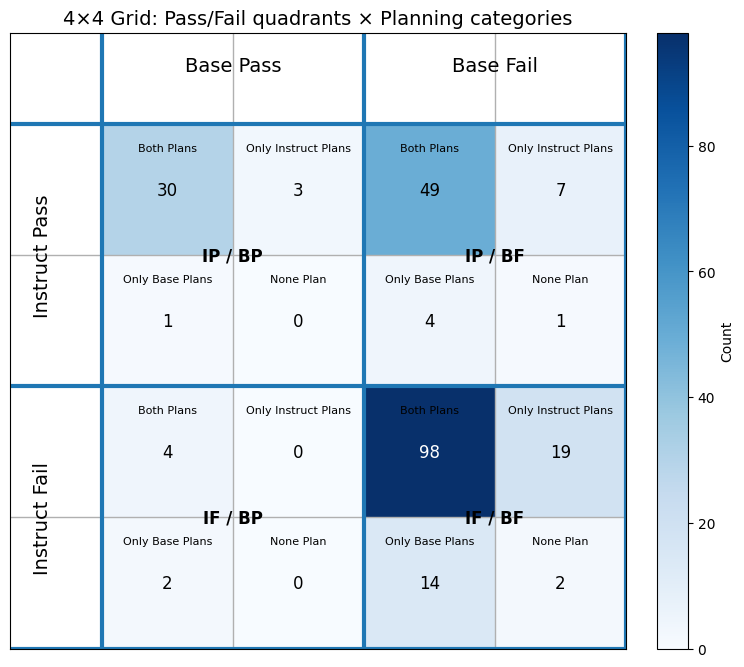

In [42]:
ax = plot_4x4_plan_grid(more_diff_data, with_e = True)
plt.show()

In [ ]:
more_diff_data = [entry for entry in data if _filter_similar_answers(entry, 10, 0.4)]
len(more_diff_data)

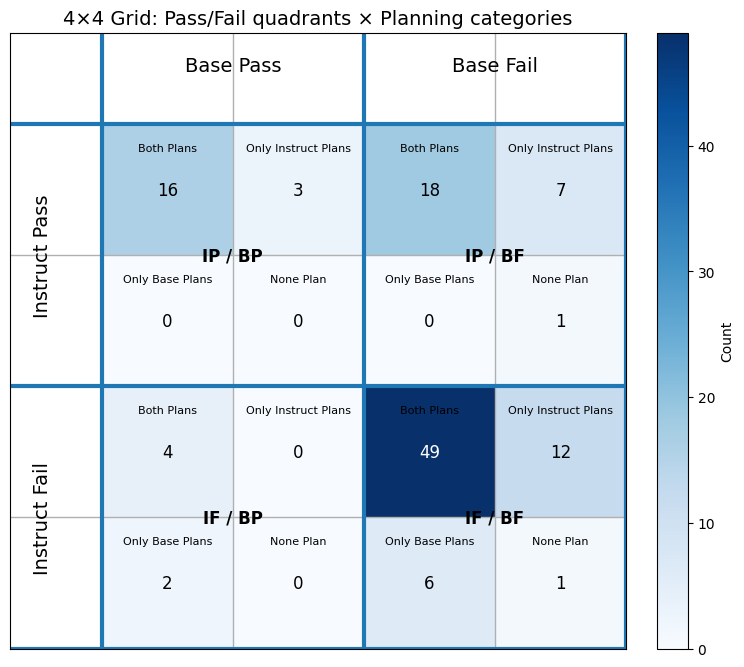

In [ ]:
ax = plot_4x4_plan_grid(more_diff_data, with_e = True)
plt.show()